In [22]:
# Gemeinsamen Merge repo-relativ laden
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Repository-Wurzel mit .git wurde nicht gefunden.")


MERGED_FILE = (
    find_repo_root()
    / "dataset"
    / "cleaned"
    / "merged"
    / "all_sources_attacks_merged_analysis_ready.csv"
)
if not MERGED_FILE.exists():
    raise FileNotFoundError(
        f"Merge-Datei fehlt: {MERGED_FILE}\n"
        "Bitte zuerst dataset/raw/Merge all files.ipynb vollständig ausführen."
    )

combined = pd.read_csv(MERGED_FILE, low_memory=False)
print("Loaded file:", MERGED_FILE)
print("Shape:", combined.shape)
display(combined.head())


Loaded file: d:\HS Hof files all sem\HS Hof files Sem 7\Data Anlayse & Mining\Repo\dataset\cleaned\merged\all_sources_attacks_merged_analysis_ready.csv
Shape: (4066498, 36)


,attack_id,patient_id,source_group,headache,migraine,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,attack_datetime,...,attack_date,year,month,month_name,weekday_num,weekday_name,season,week_start,migraine_group,age_group
0,117,72741515,AppOnly,True,False,False,False,True,False,2020-06-08,...,2020-06-08,2020,6,Juni,0,Montag,Sommer,2020-06-08,Nicht-Migraene,30-44
1,118,72741515,AppOnly,True,True,False,False,True,False,2020-06-09,...,2020-06-09,2020,6,Juni,1,Dienstag,Sommer,2020-06-08,Migraene,30-44
2,127,44203359,AppOnly,True,True,False,True,True,False,2020-06-19,...,2020-06-19,2020,6,Juni,4,Freitag,Sommer,2020-06-15,Migraene,45-59
3,128,44203359,AppOnly,True,True,False,True,True,False,2020-06-20,...,2020-06-20,2020,6,Juni,5,Samstag,Sommer,2020-06-15,Migraene,45-59
4,129,44203359,AppOnly,True,True,False,True,True,False,2020-06-21,...,2020-06-21,2020,6,Juni,6,Sonntag,Sommer,2020-06-15,Migraene,45-59


In [23]:
# ============================================================
# BASIC TYPE CLEANING AFTER CSV LOAD
# ============================================================

# Convert datetime columns
date_cols = [
    "attack_datetime",
    "date_registration",
    "first_app_entry_date",
    "last_app_entry_date",
    "week_start"
]

for col in date_cols:
    if col in combined.columns:
        combined[col] = pd.to_datetime(combined[col], errors="coerce")

# Convert numeric columns
numeric_cols = [
    "age_reg",
    "birthyear",
    "intensity",
    "duration",
    "entries_app",
    "headache_entries_app",
    "migraine_entries_app",
    "year",
    "month",
    "weekday_num"
]

for col in numeric_cols:
    if col in combined.columns:
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

# Convert boolean-like columns
def to_bool_or_na(x):
    if pd.isna(x):
        return pd.NA

    x = str(x).strip().lower()

    if x in ["true", "1", "yes", "ja", "wahr"]:
        return True
    if x in ["false", "0", "no", "nein", "falsch"]:
        return False

    return pd.NA

for col in ["headache", "migraine", "comment_menstruation"]:
    if col in combined.columns:
        combined[col] = combined[col].apply(to_bool_or_na).astype("boolean")

print("Types cleaned.")

print("\nImportant dtypes:")
display(combined[[
    "attack_datetime",
    "attack_id",
    "patient_id",
    "age_reg",
    "headache",
    "migraine",
    "intensity",
    "duration"
]].dtypes)

Types cleaned.

Important dtypes:


attack_datetime    datetime64[us]
attack_id                   int64
patient_id                  int64
age_reg                     int64
headache                  boolean
migraine                  boolean
intensity                   int64
duration                    int64
dtype: object

In [24]:
# ============================================================
# PHASE 2 + PHASE 3
# Finaler Analyse-Datensatz + Deskriptive Analyse
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

# ------------------------------------------------------------
# 1. FINALER ANALYSEFILTER
# ------------------------------------------------------------

print("Ausgangsdatensatz:")
print("Zeilen / Attacken:", len(combined))
print("Eindeutige Patient:innen:", combined["patient_id"].nunique())

# Sicherheitschecks
print("\nSicherheitscheck headache:")
display(combined["headache"].value_counts(dropna=False).rename_axis("headache").reset_index(name="anzahl_zeilen"))

print("\nSicherheitscheck migraine:")
display(combined["migraine"].value_counts(dropna=False).rename_axis("migraine").reset_index(name="anzahl_zeilen"))

print("\nSicherheitscheck age_reg:")
print("Fehlende age_reg:", combined["age_reg"].isna().sum())
print("age_reg < 18:", (combined["age_reg"] < 18).sum())
print("age_reg >= 18:", (combined["age_reg"] >= 18).sum())

print("\nSicherheitscheck attack_datetime:")
print("Fehlende attack_datetime:", combined["attack_datetime"].isna().sum())

# Finaler Filter:
# Laut Prof: nur Patient:innen >= 18 Jahre
# attack_datetime muss vorhanden sein, sonst kann keine Zeitreihenanalyse gemacht werden
df_analysis = combined[
    (combined["age_reg"] >= 18)
    & (combined["attack_datetime"].notna())
].copy()

print("\nFinaler Analyse-Datensatz:")
print("Zeilen / Attacken:", len(df_analysis))
print("Eindeutige Patient:innen:", df_analysis["patient_id"].nunique())

print("\nEntfernte Zeilen durch Filter:")
print(len(combined) - len(df_analysis))


Ausgangsdatensatz:
Zeilen / Attacken: 4066498
Eindeutige Patient:innen: 64212

Sicherheitscheck headache:


,headache,anzahl_zeilen
0,True,4066498



Sicherheitscheck migraine:


,migraine,anzahl_zeilen
0,False,2439707
1,True,1626791



Sicherheitscheck age_reg:
Fehlende age_reg: 0
age_reg < 18: 110310
age_reg >= 18: 3956188

Sicherheitscheck attack_datetime:
Fehlende attack_datetime: 0

Finaler Analyse-Datensatz:
Zeilen / Attacken: 3956188
Eindeutige Patient:innen: 61622

Entfernte Zeilen durch Filter:
110310


In [25]:
# ------------------------------------------------------------
# 2. AGE GROUP UND MIGRAINE GROUP SICHER ERSTELLEN
# ------------------------------------------------------------

df_analysis["age_group"] = pd.cut(
    df_analysis["age_reg"],
    bins=[18, 30, 45, 60, np.inf],
    right=False,
    labels=["18-29", "30-44", "45-59", "60+"]
)

def migraine_group_from_bool(x):
    if pd.isna(x):
        return np.nan
    if bool(x) is True:
        return "Migraene"
    if bool(x) is False:
        return "Nicht-Migraene"
    return np.nan

df_analysis["migraine_group"] = df_analysis["migraine"].apply(migraine_group_from_bool)

In [26]:
# ------------------------------------------------------------
# 3. PATIENT-LEVEL DATAFRAME
# Eine Zeile pro Patient:in
# ------------------------------------------------------------

patient_cols = [
    "patient_id",
    "source_group",
    "gender",
    "age_reg",
    "age_group",
    "birthyear",
    "date_registration",
    "first_app_entry",
    "last_app_entry",
    "entries_app",
    "headache_entries_app",
    "migraine_entries_app"
]

existing_patient_cols = [col for col in patient_cols if col in df_analysis.columns]

patients_analysis = (
    df_analysis[existing_patient_cols]
    .drop_duplicates(subset=["patient_id"])
    .copy()
)

print("\nPatient-Level Datensatz:")
print("Eine Zeile pro Patient:in")
print("Anzahl Patient:innen:", len(patients_analysis))
display(patients_analysis.head())



Patient-Level Datensatz:
Eine Zeile pro Patient:in
Anzahl Patient:innen: 61622


,patient_id,source_group,gender,age_reg,age_group,birthyear,date_registration,first_app_entry,last_app_entry,entries_app,headache_entries_app,migraine_entries_app
0,72741515,AppOnly,männlich,40,30-44,1980,2020-06-20,2020-06-07,2026-02-15,2056.0,174.0,30.0
2,44203359,AppOnly,weiblich,59,45-59,1961,2020-06-26,2020-06-19,2023-10-17,1166.0,148.0,117.0
9,14736818,AppOnly,weiblich,22,18-29,1998,2020-06-29,2020-06-15,2020-06-28,14.0,7.0,3.0
16,33315147,AppOnly,männlich,40,30-44,1980,2020-06-28,2020-06-14,2026-02-15,1989.0,236.0,40.0
20,44806461,AppOnly,weiblich,22,18-29,1998,2020-07-01,2020-07-01,2026-01-15,154.0,144.0,93.0


In [27]:
# ------------------------------------------------------------
# 4. PATIENT:INNEN DESKRIPTIV
# ------------------------------------------------------------

print("\n==============================")
print("PATIENT:INNEN DESKRIPTIV")
print("==============================")

patient_overview = pd.DataFrame({
    "kennzahl": [
        "Anzahl eindeutige Patient:innen",
        "Mittleres Alter bei Registrierung",
        "Median Alter bei Registrierung",
        "Min. Alter bei Registrierung",
        "Max. Alter bei Registrierung"
    ],
    "wert": [
        patients_analysis["patient_id"].nunique(),
        round(patients_analysis["age_reg"].mean(), 2),
        round(patients_analysis["age_reg"].median(), 2),
        patients_analysis["age_reg"].min(),
        patients_analysis["age_reg"].max()
    ]
})

display(patient_overview)

print("\nGeschlecht: Anzahl Patient:innen")
gender_patient_summary = (
    patients_analysis
    .groupby("gender", dropna=False)
    .agg(
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

gender_patient_summary["anteil_patienten_prozent"] = (
    gender_patient_summary["anzahl_patienten"]
    / gender_patient_summary["anzahl_patienten"].sum()
    * 100
).round(2)

display(gender_patient_summary)

print("\nAltersgruppen: Anzahl Patient:innen")
age_patient_summary = (
    patients_analysis
    .groupby("age_group", dropna=False, observed=False)
    .agg(
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

age_patient_summary["anteil_patienten_prozent"] = (
    age_patient_summary["anzahl_patienten"]
    / age_patient_summary["anzahl_patienten"].sum()
    * 100
).round(2)

display(age_patient_summary)

print("\nDatenquelle: Anzahl Patient:innen")
source_patient_summary = (
    patients_analysis
    .groupby("source_group", dropna=False)
    .agg(
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

source_patient_summary["anteil_patienten_prozent"] = (
    source_patient_summary["anzahl_patienten"]
    / source_patient_summary["anzahl_patienten"].sum()
    * 100
).round(2)

display(source_patient_summary)


PATIENT:INNEN DESKRIPTIV


,kennzahl,wert
0,Anzahl eindeutige Patient:innen,61622.00
1,Mittleres Alter bei Registrierung,35.98
2,Median Alter bei Registrierung,34.00
3,Min. Alter bei Registrierung,18.00
4,Max. Alter bei Registrierung,125.00



Geschlecht: Anzahl Patient:innen


,gender,anzahl_patienten,anteil_patienten_prozent
0,divers,408,0.66
1,männlich,11173,18.13
2,weiblich,50041,81.21



Altersgruppen: Anzahl Patient:innen


,age_group,anzahl_patienten,anteil_patienten_prozent
0,18-29,22941,37.23
1,30-44,22993,37.31
2,45-59,13294,21.57
3,60+,2394,3.88



Datenquelle: Anzahl Patient:innen


,source_group,anzahl_patienten,anteil_patienten_prozent
0,AppOnly,56311,91.38
1,Visit,5311,8.62


In [28]:
# ------------------------------------------------------------
# 5. ATTACK-LEVEL DESKRIPTIV
# Eine Zeile = eine Attacke / ein Kopfschmerzeintrag
# ------------------------------------------------------------

print("\n==============================")
print("ANFALLDATEN DESKRIPTIV")
print("==============================")

attack_overview = pd.DataFrame({
    "kennzahl": [
        "Anzahl dokumentierte Attacken",
        "Anzahl eindeutige Patient:innen",
        "Erstes Anfalldatum",
        "Letztes Anfalldatum",
        "Mittlere Intensität",
        "Median Intensität",
        "Mittlere Dauer",
        "Median Dauer"
    ],
    "wert": [
        len(df_analysis),
        df_analysis["patient_id"].nunique(),
        df_analysis["attack_datetime"].min(),
        df_analysis["attack_datetime"].max(),
        round(df_analysis["intensity"].mean(), 2),
        round(df_analysis["intensity"].median(), 2),
        round(df_analysis["duration"].mean(), 2),
        round(df_analysis["duration"].median(), 2)
    ]
})

display(attack_overview)

print("\nMigraine group: Anzahl Attacken und Patient:innen")
migraine_summary = (
    df_analysis
    .groupby("migraine_group", dropna=False)
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

migraine_summary["anteil_attacken_prozent"] = (
    migraine_summary["anzahl_attacken"]
    / migraine_summary["anzahl_attacken"].sum()
    * 100
).round(2)

display(migraine_summary)

print("\nIntensität Verteilung")
intensity_summary = (
    df_analysis
    .groupby("intensity", dropna=False)
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
    .sort_values("intensity")
)

intensity_summary["anteil_attacken_prozent"] = (
    intensity_summary["anzahl_attacken"]
    / intensity_summary["anzahl_attacken"].sum()
    * 100
).round(2)

display(intensity_summary)

print("\nDauer Verteilung: wichtige Kennzahlen (in Minuten)")
duration_summary = df_analysis["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("duration")
display(duration_summary)



ANFALLDATEN DESKRIPTIV


,kennzahl,wert
0,Anzahl dokumentierte Attacken,3956188
1,Anzahl eindeutige Patient:innen,61622
2,Erstes Anfalldatum,2020-06-08 00:00:00
3,Letztes Anfalldatum,2026-02-15 00:00:00
4,Mittlere Intensität,4.56
5,Median Intensität,4.0
6,Mittlere Dauer,592.75
7,Median Dauer,480.0



Migraine group: Anzahl Attacken und Patient:innen


,migraine_group,anzahl_attacken,anzahl_patienten,anteil_attacken_prozent
0,Migraene,1597414,48873,40.38
1,Nicht-Migraene,2358774,57940,59.62



Intensität Verteilung


,intensity,anzahl_attacken,anzahl_patienten,anteil_attacken_prozent
0,0,27393,5865,0.69
1,1,282215,28599,7.13
2,2,499245,40914,12.62
3,3,641938,46599,16.23
4,4,625283,46999,15.81
5,5,566188,46811,14.31
6,6,462463,43317,11.69
7,7,377599,39456,9.54
8,8,278823,33352,7.05
9,9,110948,19645,2.80



Dauer Verteilung: wichtige Kennzahlen (in Minuten)


,duration
count,3.956188e+06
mean,5.927479e+02
std,4.144318e+02
min,6.000000e+01
25%,3.000000e+02
50%,4.800000e+02
75%,8.400000e+02
90%,1.440000e+03
95%,1.440000e+03
max,1.440000e+03


In [29]:
# ------------------------------------------------------------
# 6. ATTACKEN PRO PATIENT:IN
# ------------------------------------------------------------

print("\nAttacken pro Patient:in")

attacks_per_patient = (
    df_analysis
    .groupby("patient_id")
    .agg(
        anzahl_attacken=("attack_id", "count"),
        gender=("gender", "first"),
        age_reg=("age_reg", "first"),
        age_group=("age_group", "first"),
        source_group=("source_group", "first")
    )
    .reset_index()
)

display(attacks_per_patient["anzahl_attacken"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("attacken_pro_patient"))

print("\nTop 10 Patient:innen nach Anzahl dokumentierter Attacken")
display(attacks_per_patient.sort_values("anzahl_attacken", ascending=False).head(10))


Attacken pro Patient:in


,attacken_pro_patient
count,61622.000000
mean,64.200902
std,115.512411
min,1.000000
25%,7.000000
50%,23.000000
75%,71.000000
90%,170.000000
95%,261.000000
max,1974.000000



Top 10 Patient:innen nach Anzahl dokumentierter Attacken


,patient_id,anzahl_attacken,gender,age_reg,age_group,source_group
24584,45861150,1974,männlich,52,45-59,AppOnly
33477,58668734,1937,männlich,63,60+,AppOnly
10525,25124162,1906,weiblich,42,30-44,Visit
47712,79404720,1837,weiblich,40,30-44,Visit
47145,78562347,1787,weiblich,19,18-29,Visit
9128,23072369,1771,männlich,31,30-44,Visit
48094,79983539,1737,weiblich,29,18-29,Visit
46396,77473155,1719,weiblich,31,30-44,Visit
58765,95697268,1697,weiblich,40,30-44,Visit
32203,56863116,1683,weiblich,33,30-44,Visit


In [30]:
# ------------------------------------------------------------
# 7. ZEITLICHE VERTEILUNGEN
# ------------------------------------------------------------

print("\n==============================")
print("ZEITLICHE VERTEILUNGEN")
print("==============================")

weekday_order = [
    "Montag", "Dienstag", "Mittwoch", "Donnerstag",
    "Freitag", "Samstag", "Sonntag"
]

month_order = [
    "Januar", "Februar", "Maerz", "April", "Mai", "Juni",
    "Juli", "August", "September", "Oktober", "November", "Dezember"
]

season_order = ["Winter", "Fruehling", "Sommer", "Herbst"]

print("\nWochentage: Anzahl Attacken und Patient:innen")
weekday_summary = (
    df_analysis
    .groupby("weekday_name", dropna=False)
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

weekday_summary["weekday_name"] = pd.Categorical(
    weekday_summary["weekday_name"],
    categories=weekday_order,
    ordered=True
)

weekday_summary["anteil_attacken_prozent"] = (
    weekday_summary["anzahl_attacken"]
    / weekday_summary["anzahl_attacken"].sum()
    * 100
).round(2)

weekday_summary = weekday_summary.sort_values("weekday_name")
display(weekday_summary)

print("\nMonate: Anzahl Attacken und Patient:innen")
month_summary = (
    df_analysis
    .groupby("month_name", dropna=False)
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

month_summary["month_name"] = pd.Categorical(
    month_summary["month_name"],
    categories=month_order,
    ordered=True
)

month_summary["anteil_attacken_prozent"] = (
    month_summary["anzahl_attacken"]
    / month_summary["anzahl_attacken"].sum()
    * 100
).round(2)

month_summary = month_summary.sort_values("month_name")
display(month_summary)

print("\nJahreszeiten: Anzahl Attacken und Patient:innen")
season_summary = (
    df_analysis
    .groupby("season", dropna=False)
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

season_summary["season"] = pd.Categorical(
    season_summary["season"],
    categories=season_order,
    ordered=True
)

season_summary["anteil_attacken_prozent"] = (
    season_summary["anzahl_attacken"]
    / season_summary["anzahl_attacken"].sum()
    * 100
).round(2)

season_summary = season_summary.sort_values("season")
display(season_summary)

print("\nJahre: Anzahl Attacken und Patient:innen")
year_summary = (
    df_analysis
    .groupby("year", dropna=False)
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
    .sort_values("year")
)

year_summary["anteil_attacken_prozent"] = (
    year_summary["anzahl_attacken"]
    / year_summary["anzahl_attacken"].sum()
    * 100
).round(2)

display(year_summary)




ZEITLICHE VERTEILUNGEN

Wochentage: Anzahl Attacken und Patient:innen


,weekday_name,anzahl_attacken,anzahl_patienten,anteil_attacken_prozent
4,Montag,544850,50392,13.77
0,Dienstag,563836,50632,14.25
3,Mittwoch,584877,51094,14.78
1,Donnerstag,581732,50919,14.70
2,Freitag,572366,50266,14.47
5,Samstag,573942,49721,14.51
6,Sonntag,534585,49137,13.51



Monate: Anzahl Attacken und Patient:innen


,month_name,anzahl_attacken,anzahl_patienten,anteil_attacken_prozent
4,Januar,417293,34014,10.55
3,Februar,328568,33328,8.31
7,Maerz,275492,23543,6.96
0,April,275453,24190,6.96
8,Mai,292515,25275,7.39
6,Juni,290143,25733,7.33
5,Juli,317237,27021,8.02
1,August,326243,27452,8.25
11,September,334785,28548,8.46
10,Oktober,361978,29830,9.15



Jahreszeiten: Anzahl Attacken und Patient:innen


,season,anzahl_attacken,anzahl_patienten,anteil_attacken_prozent
3,Winter,1119179,42573,28.29
0,Fruehling,843460,31797,21.32
2,Sommer,933623,34597,23.60
1,Herbst,1059926,38622,26.79



Jahre: Anzahl Attacken und Patient:innen


,year,anzahl_attacken,anzahl_patienten,anteil_attacken_prozent
0,2020,14324,745,0.36
1,2021,113602,2844,2.87
2,2022,258429,6727,6.53
3,2023,559229,14468,14.14
4,2024,1041526,24655,26.33
5,2025,1701943,37959,43.02
6,2026,267135,24301,6.75


In [31]:
first_entry_col = None
last_entry_col = None

for candidate in ["first_app_entry_date", "first_app_entry"]:
    if candidate in df_analysis.columns:
        first_entry_col = candidate
        break

for candidate in ["last_app_entry_date", "last_app_entry"]:
    if candidate in df_analysis.columns:
        last_entry_col = candidate
        break

print("Detected first app entry column:", first_entry_col)
print("Detected last app entry column:", last_entry_col)

# Convert relevant date columns safely
if first_entry_col is not None:
    df_analysis[first_entry_col] = pd.to_datetime(df_analysis[first_entry_col], errors="coerce")

if last_entry_col is not None:
    df_analysis[last_entry_col] = pd.to_datetime(df_analysis[last_entry_col], errors="coerce")

df_analysis["attack_datetime"] = pd.to_datetime(df_analysis["attack_datetime"], errors="coerce")

Detected first app entry column: first_app_entry_date
Detected last app entry column: last_app_entry_date


In [32]:
# ------------------------------------------------------------
# 2. Patient-level observation / participation duration
# ------------------------------------------------------------

patient_duration_parts = {
    "anzahl_attacken": ("attack_id", "count"),
    "first_attack_datetime": ("attack_datetime", "min"),
    "last_attack_datetime": ("attack_datetime", "max"),
    "gender": ("gender", "first"),
    "age_reg": ("age_reg", "first"),
    "age_group": ("age_group", "first"),
    "source_group": ("source_group", "first"),
}

if "entries_app" in df_analysis.columns:
    patient_duration_parts["entries_app"] = ("entries_app", "first")

if "headache_entries_app" in df_analysis.columns:
    patient_duration_parts["headache_entries_app"] = ("headache_entries_app", "first")

if "migraine_entries_app" in df_analysis.columns:
    patient_duration_parts["migraine_entries_app"] = ("migraine_entries_app", "first")

if first_entry_col is not None:
    patient_duration_parts["first_app_entry"] = (first_entry_col, "first")

if last_entry_col is not None:
    patient_duration_parts["last_app_entry"] = (last_entry_col, "first")

patient_descriptive_extended = (
    df_analysis
    .groupby("patient_id")
    .agg(**patient_duration_parts)
    .reset_index()
)

# Attack-based observation duration
patient_descriptive_extended["attack_observation_days"] = (
    patient_descriptive_extended["last_attack_datetime"]
    - patient_descriptive_extended["first_attack_datetime"]
).dt.days + 1

patient_descriptive_extended["attack_observation_months"] = (
    patient_descriptive_extended["attack_observation_days"] / 30.4375
)

# App-based participation duration if app entry dates exist
if "first_app_entry" in patient_descriptive_extended.columns and "last_app_entry" in patient_descriptive_extended.columns:
    patient_descriptive_extended["app_participation_days"] = (
        patient_descriptive_extended["last_app_entry"]
        - patient_descriptive_extended["first_app_entry"]
    ).dt.days + 1

    patient_descriptive_extended["app_participation_months"] = (
        patient_descriptive_extended["app_participation_days"] / 30.4375
    )
else:
    patient_descriptive_extended["app_participation_days"] = np.nan
    patient_descriptive_extended["app_participation_months"] = np.nan

# Avoid division by zero or negative weird values
patient_descriptive_extended.loc[
    patient_descriptive_extended["attack_observation_months"] <= 0,
    "attack_observation_months"
] = np.nan

patient_descriptive_extended.loc[
    patient_descriptive_extended["app_participation_months"] <= 0,
    "app_participation_months"
] = np.nan

# Attack frequency per patient per month
patient_descriptive_extended["attacks_per_attack_observation_month (anzahl Attacks/attack_observation_month)"] = (
    patient_descriptive_extended["anzahl_attacken"]
    / patient_descriptive_extended["attack_observation_months"]
)

patient_descriptive_extended["attacks_per_app_participation_month(anzahl Attacks/app_participation_month)"] = (
    patient_descriptive_extended["anzahl_attacken"]
    / patient_descriptive_extended["app_participation_months"]
)

print("\nPatient-level extended descriptive dataset:")
display(patient_descriptive_extended.head())


Patient-level extended descriptive dataset:


,patient_id,anzahl_attacken,first_attack_datetime,last_attack_datetime,gender,age_reg,age_group,source_group,entries_app,headache_entries_app,migraine_entries_app,first_app_entry,last_app_entry,attack_observation_days,attack_observation_months,app_participation_days,app_participation_months,attacks_per_attack_observation_month (anzahl Attacks/attack_observation_month),attacks_per_app_participation_month(anzahl Attacks/app_participation_month)
0,10005187,9,2024-04-27,2024-05-19,weiblich,21,18-29,AppOnly,19.0,9.0,0.0,2024-04-22,2024-05-19,23,0.755647,28,0.919918,11.910326,9.783482
1,10005708,10,2021-09-14,2021-11-19,männlich,29,18-29,AppOnly,53.0,10.0,5.0,2021-09-08,2021-11-22,67,2.201232,76,2.496920,4.542910,4.004934
2,10005818,22,2025-03-08,2025-12-02,weiblich,57,45-59,AppOnly,24.0,22.0,16.0,2025-03-08,2025-12-02,270,8.870637,270,8.870637,2.480093,2.480093
3,10007520,122,2023-06-21,2024-10-13,weiblich,61,60+,Visit,517.0,122.0,10.0,2023-06-21,2024-11-18,481,15.802875,517,16.985626,7.720114,7.182544
4,10009199,24,2025-09-28,2025-11-16,männlich,41,30-44,AppOnly,51.0,24.0,2.0,2025-09-28,2025-11-18,50,1.642710,52,1.708419,14.610000,14.048077


In [33]:
# ------------------------------------------------------------
# 3. Teilnahmedauer / Beobachtungsdauer summaries
# ------------------------------------------------------------

print("\nTeilnahmedauer / Beobachtungsdauer pro Patient:in")

duration_cols_to_describe = [
    "attack_observation_days",
    "attack_observation_months",
    "app_participation_days",
    "app_participation_months"
]

existing_duration_cols = [
    col for col in duration_cols_to_describe
    if col in patient_descriptive_extended.columns
]

duration_patient_summary = (
    patient_descriptive_extended[existing_duration_cols]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .T
)

display(duration_patient_summary)


Teilnahmedauer / Beobachtungsdauer pro Patient:in


,count,mean,std,min,25%,50%,75%,90%,95%,max
attack_observation_days,61622.0,262.076628,350.737627,1.000000,24.000000,114.000000,358.000000,750.000000,1039.000000,2068.000000
attack_observation_months,61622.0,8.610320,11.523207,0.032854,0.788501,3.745380,11.761807,24.640657,34.135524,67.942505
app_participation_days,61622.0,271.306644,354.167590,1.000000,29.000000,123.000000,372.000000,767.000000,1056.000000,2080.000000
app_participation_months,61622.0,8.913565,11.635896,0.032854,0.952772,4.041068,12.221766,25.199179,34.694045,68.336756


In [34]:
# ------------------------------------------------------------
# 4. Anfallhäufigkeit pro Monat pro Patient:in
# ------------------------------------------------------------

print("\nAnfallhäufigkeit pro Monat pro Patient:in")

# Rename long explanatory column names back to clean technical names
rename_frequency_cols = {
    "attacks_per_attack_observation_month (anzahl Attacks/attack_observation_month)": "attacks_per_attack_observation_month",
    "attacks_per_app_participation_month(anzahl Attacks/app_participation_month)": "attacks_per_app_participation_month"
}

patient_descriptive_extended = patient_descriptive_extended.rename(
    columns=rename_frequency_cols
)

frequency_cols = [
    "anzahl_attacken",
    "attacks_per_attack_observation_month",
    "attacks_per_app_participation_month"
]

frequency_summary = (
    patient_descriptive_extended[frequency_cols]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .T
)

# Only rename for display, not inside the actual dataframe
frequency_summary = frequency_summary.rename(index={
    "anzahl_attacken": "Anzahl Attacken pro Patient:in",
    "attacks_per_attack_observation_month": "Attacken pro Monat basierend auf erster bis letzter Attacke",
    "attacks_per_app_participation_month": "Attacken pro Monat basierend auf erster bis letzter App-Nutzung"
})

display(frequency_summary)


Anfallhäufigkeit pro Monat pro Patient:in


,count,mean,std,min,25%,50%,75%,90%,95%,max
Anzahl Attacken pro Patient:in,61622.0,64.200902,115.512411,1.000000,7.000000,23.000000,71.000000,170.000000,261.0000,1974.0000
Attacken pro Monat basierend auf erster bis letzter Attacke,61622.0,11.906723,9.470464,0.033247,4.665602,8.446008,16.692496,30.437500,30.4375,30.4375
Attacken pro Monat basierend auf erster bis letzter App-Nutzung,61622.0,10.620119,8.830332,0.028715,4.150568,7.580440,14.204167,29.714856,30.4375,30.4375


In [35]:
# ------------------------------------------------------------
# 5. App-entry summaries
# ------------------------------------------------------------

app_entry_cols = [
    "entries_app",
    "headache_entries_app",
    "migraine_entries_app"
]

existing_app_entry_cols = [
    col for col in app_entry_cols
    if col in patient_descriptive_extended.columns
]

if len(existing_app_entry_cols) > 0:
    print("\nApp-entry summaries auf Patient:innenebene")

    app_entry_summary = (
        patient_descriptive_extended[existing_app_entry_cols]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
        .T
    )

    display(app_entry_summary)
else:
    print("\nKeine App-entry Spalten gefunden.")


App-entry summaries auf Patient:innenebene


,count,mean,std,min,25%,50%,75%,90%,95%,max
entries_app,61622.0,185.729739,299.629236,1.0,12.0,55.0,222.0,563.0,846.0,2057.0
headache_entries_app,61622.0,64.200902,115.512411,1.0,7.0,23.0,71.0,170.0,261.0,1974.0
migraine_entries_app,61622.0,25.922787,63.910171,0.0,1.0,5.0,21.0,69.0,127.0,1820.0


In [36]:
# ------------------------------------------------------------
# 6. Migraine share per patient
# ------------------------------------------------------------

print("\nMigraine share per patient")

migraine_per_patient = (
    df_analysis
    .groupby("patient_id")
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_migraene_attacken=("migraine", lambda x: (x == True).sum()),
        anzahl_nicht_migraene_attacken=("migraine", lambda x: (x == False).sum()),
        gender=("gender", "first"),
        age_reg=("age_reg", "first"),
        age_group=("age_group", "first"),
        source_group=("source_group", "first")
    )
    .reset_index()
)

migraine_per_patient["migraine_attack_share_percent"] = (
    migraine_per_patient["anzahl_migraene_attacken"]
    / migraine_per_patient["anzahl_attacken"]
    * 100
)

display(
    migraine_per_patient[
        [
            "anzahl_attacken",
            "anzahl_migraene_attacken",
            "anzahl_nicht_migraene_attacken",
            "migraine_attack_share_percent"
        ]
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T
)



Migraine share per patient


,count,mean,std,min,25%,50%,75%,90%,95%,max
anzahl_attacken,61622.0,64.200902,115.512411,1.0,7.0,23.0,71.0,170.0,261.0,1974.0
anzahl_migraene_attacken,61622.0,25.922787,63.910171,0.0,1.0,5.0,21.0,69.0,127.0,1820.0
anzahl_nicht_migraene_attacken,61622.0,38.278115,78.440829,0.0,3.0,13.0,39.0,97.0,159.0,1937.0
migraine_attack_share_percent,61622.0,35.526172,32.535665,0.0,4.545455,28.169014,60.0,88.332685,100.0,100.0


In [37]:
# ------------------------------------------------------------
# 7. Monthly attack frequency: calendar-month level
# ------------------------------------------------------------

print("\nKalendermonatliche Anfallhäufigkeit im Gesamtdatensatz")

monthly_attack_summary = (
    df_analysis
    .groupby(["year", "month"])
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
    .sort_values(["year", "month"])
)

monthly_attack_summary["year_month"] = (
    monthly_attack_summary["year"].astype(int).astype(str)
    + "-"
    + monthly_attack_summary["month"].astype(int).astype(str).str.zfill(2)
)

monthly_attack_summary["attacken_pro_patient_im_monat"] = (
    monthly_attack_summary["anzahl_attacken"]
    / monthly_attack_summary["anzahl_patienten"]
)

display(monthly_attack_summary.head(12))
display(monthly_attack_summary.tail(12))

print("\nSummary der Monatswerte:")
display(
    monthly_attack_summary[
        ["anzahl_attacken", "anzahl_patienten", "attacken_pro_patient_im_monat"]
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T
)



Kalendermonatliche Anfallhäufigkeit im Gesamtdatensatz


,year,month,anzahl_attacken,anzahl_patienten,year_month,attacken_pro_patient_im_monat
0,2020,6,32,12,2020-06,2.666667
1,2020,7,604,93,2020-07,6.494624
2,2020,8,1282,161,2020-08,7.962733
3,2020,9,1906,227,2020-09,8.396476
4,2020,10,2847,353,2020-10,8.065156
5,2020,11,3745,448,2020-11,8.359375
6,2020,12,3908,470,2020-12,8.314894
7,2021,1,5336,647,2021-01,8.247295
8,2021,2,5837,722,2021-02,8.084488
9,2021,3,6698,743,2021-03,9.014805


,year,month,anzahl_attacken,anzahl_patienten,year_month,attacken_pro_patient_im_monat
57,2025,3,131616,16419,2025-03,8.016079
58,2025,4,129843,16719,2025-04,7.766194
59,2025,5,139280,17657,2025-05,7.888090
60,2025,6,136304,17805,2025-06,7.655378
61,2025,7,149107,18629,2025-07,8.004026
62,2025,8,150947,18803,2025-08,8.027815
63,2025,9,152268,19385,2025-09,7.854939
64,2025,10,161159,20004,2025-10,8.056339
65,2025,11,156699,20328,2025-11,7.708530
66,2025,12,161045,20355,2025-12,7.911815



Summary der Monatswerte:


,count,mean,std,min,25%,50%,75%,90%,95%,max
anzahl_attacken,69.0,57336.057971,51852.889970,32.000000,13191.000000,40680.000000,90498.000000,141245.400000,154926.600000,176919.00000
anzahl_patienten,69.0,7364.927536,6760.741437,12.000000,1534.000000,5075.000000,11879.000000,18663.800000,19953.200000,22106.00000
attacken_pro_patient_im_monat,69.0,7.933766,0.863084,2.666667,7.832937,8.016079,8.247295,8.553474,8.760969,9.01722


In [38]:
# ------------------------------------------------------------
# 8. Final Phase 3 checklist
# ------------------------------------------------------------

phase3_checklist = pd.DataFrame({
    "bereich": [
        "Patient:innen: Anzahl",
        "Patient:innen: Alter/Geschlecht",
        "Patient:innen: Altersgruppen",
        "Patient:innen: App-Nutzung / Entries",
        "Patient:innen: Teilnahmedauer",
        "Anfälle: Anzahl",
        "Anfälle: Zeitraum",
        "Anfälle: Migräneanteil",
        "Anfälle: Intensitätsverteilung",
        "Anfälle: Dauerverteilung",
        "Anfälle: Wochentage",
        "Anfälle: Monate",
        "Anfälle: Jahreszeiten",
        "Anfälle: Jahre",
        "Anfallhäufigkeit pro Monat",
        "Symptome"
    ],
    "status": [
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt, falls Spalten vorhanden",
        "erledigt mit diesem Block",
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt",
        "erledigt mit diesem Block",
        "nicht möglich mit final ausgewählten Spalten"
    ]
})

print("\nPhase 3 Checklist")
display(phase3_checklist)


Phase 3 Checklist


,bereich,status
0,Patient:innen: Anzahl,erledigt
1,Patient:innen: Alter/Geschlecht,erledigt
2,Patient:innen: Altersgruppen,erledigt
3,Patient:innen: App-Nutzung / Entries,"erledigt, falls Spalten vorhanden"
4,Patient:innen: Teilnahmedauer,erledigt mit diesem Block
5,Anfälle: Anzahl,erledigt
6,Anfälle: Zeitraum,erledigt
7,Anfälle: Migräneanteil,erledigt
8,Anfälle: Intensitätsverteilung,erledigt
9,Anfälle: Dauerverteilung,erledigt


In [39]:
# ============================================================
# PHASE 3B — DESCRIPTIVE VISUALIZATIONS
# Based on the Phase 3 summary tables already created
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def add_value_labels(ax, rotation=0):
    """Write the height above every bar in a bar chart."""
    for bar in ax.patches:
        value = bar.get_height()
        if not np.isfinite(value):
            continue
        label = f"{value:,.0f}".replace(",", ".")
        ax.annotate(
            label,
            (bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            rotation=rotation,
        )
    ax.margins(y=0.12)


def save_or_show(_filename):
    """Show the current plot without writing a file."""
    plt.tight_layout()
    plt.show()

print("\n==============================")
print("PHASE 3B — DESCRIPTIVE VISUALIZATIONS")
print("==============================")




PHASE 3B — DESCRIPTIVE VISUALIZATIONS


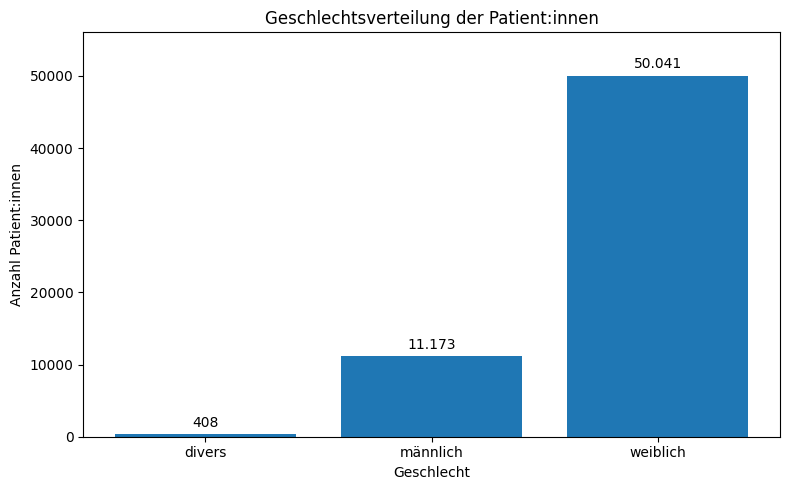

In [40]:
# ------------------------------------------------------------
# 1. Gender distribution of patients
# ------------------------------------------------------------

plot_data = gender_patient_summary.copy()

plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.bar(
    plot_data["gender"].astype(str),
    plot_data["anzahl_patienten"]
)

add_value_labels(ax)

plt.title("Geschlechtsverteilung der Patient:innen")
plt.xlabel("Geschlecht")
plt.ylabel("Anzahl Patient:innen")

save_or_show("01_gender_distribution_patients.png")

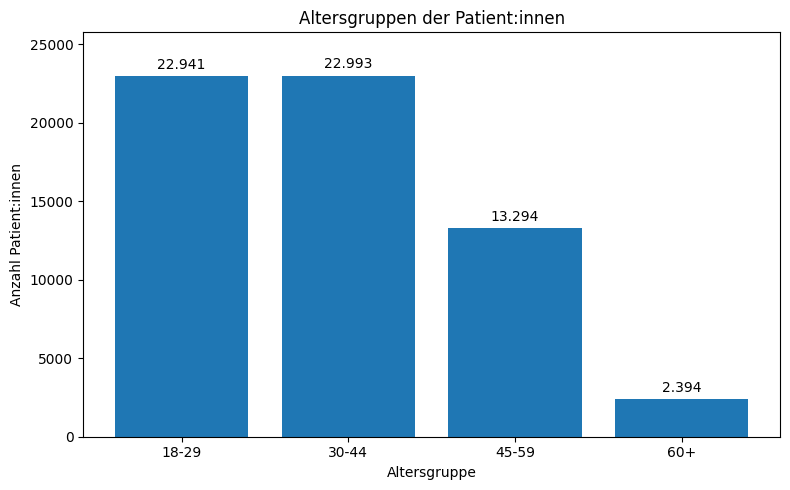

In [41]:
# ------------------------------------------------------------
# 2. Age group distribution of patients
# ------------------------------------------------------------

age_group_order = ["18-29", "30-44", "45-59", "60+"]

plot_data = age_patient_summary.copy()

plot_data["age_group"] = pd.Categorical(
    plot_data["age_group"].astype(str),
    categories=age_group_order,
    ordered=True
)

plot_data = plot_data.sort_values("age_group")

plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.bar(
    plot_data["age_group"].astype(str),
    plot_data["anzahl_patienten"]
)

add_value_labels(ax)

plt.title("Altersgruppen der Patient:innen")
plt.xlabel("Altersgruppe")
plt.ylabel("Anzahl Patient:innen")

save_or_show("02_age_group_distribution_patients.png")

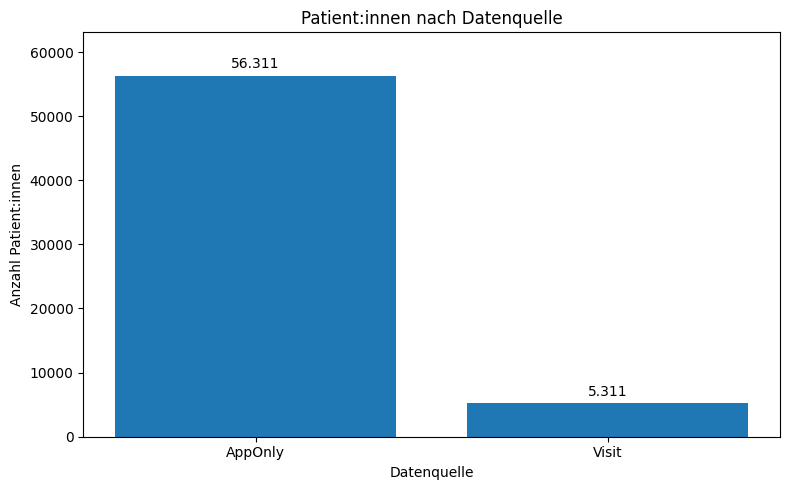

In [42]:
# ------------------------------------------------------------
# 3. Source group distribution of patients
# ------------------------------------------------------------

plot_data = source_patient_summary.copy()

plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.bar(
    plot_data["source_group"].astype(str),
    plot_data["anzahl_patienten"]
)

add_value_labels(ax)

plt.title("Patient:innen nach Datenquelle")
plt.xlabel("Datenquelle")
plt.ylabel("Anzahl Patient:innen")

save_or_show("03_source_group_distribution_patients.png")

,migraine_group,anzahl_attacken,anteil_attacken_prozent
0,Migraene,1597414,40.38
1,Nicht-Migraene,2358774,59.62


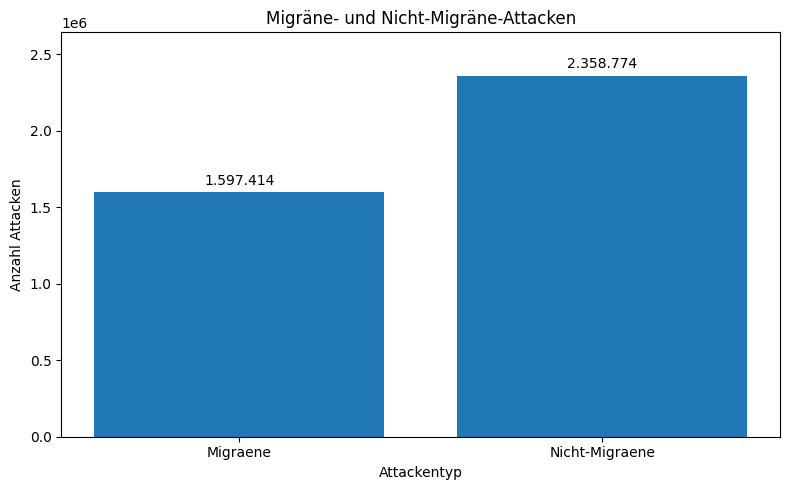

In [43]:
# ------------------------------------------------------------
# 4. Migraine vs non-migraine attack distribution
# ------------------------------------------------------------

migraine_attack_summary = (
    df_analysis
    .assign(
        migraine_group=df_analysis["migraine"].map({
            True: "Migraene",
            False: "Nicht-Migraene"
        })
    )
    .groupby("migraine_group", dropna=False)
    .agg(
        anzahl_attacken=("attack_id", "count")
    )
    .reset_index()
)

migraine_attack_summary["anteil_attacken_prozent"] = (
    migraine_attack_summary["anzahl_attacken"]
    / migraine_attack_summary["anzahl_attacken"].sum()
    * 100
).round(2)

display(migraine_attack_summary)

plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.bar(
    migraine_attack_summary["migraine_group"].astype(str),
    migraine_attack_summary["anzahl_attacken"]
)

add_value_labels(ax)

plt.title("Migräne- und Nicht-Migräne-Attacken")
plt.xlabel("Attackentyp")
plt.ylabel("Anzahl Attacken")

save_or_show("04_migraine_distribution_attacks.png")

,intensity,anzahl_attacken
0,0,27393
1,1,282215
2,2,499245
3,3,641938
4,4,625283
5,5,566188
6,6,462463
7,7,377599
8,8,278823
9,9,110948


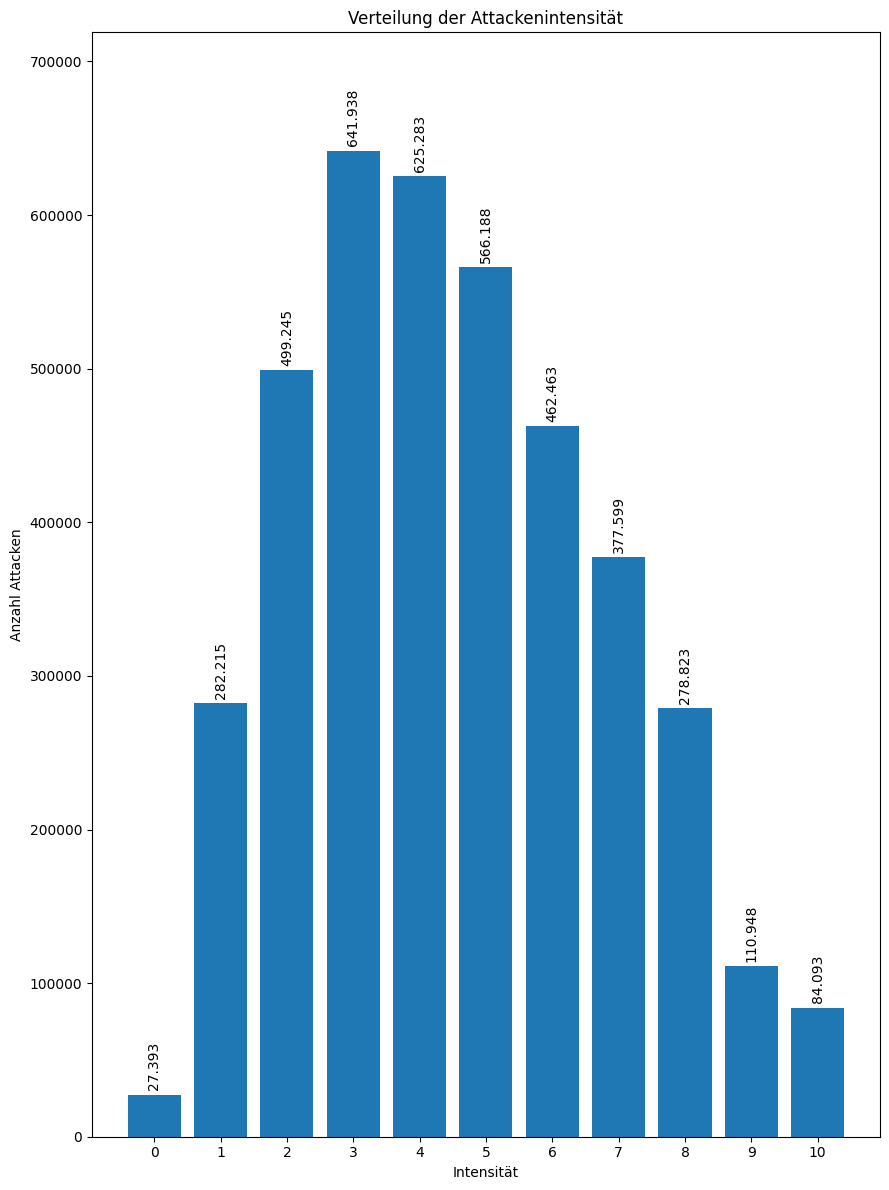

In [44]:
# ------------------------------------------------------------
# 5. Intensity distribution
# ------------------------------------------------------------

intensity_plot = (
    df_analysis
    .dropna(subset=["intensity"])
    .groupby("intensity")
    .agg(
        anzahl_attacken=("attack_id", "count")
    )
    .reset_index()
    .sort_values("intensity")
)

display(intensity_plot)

plt.figure(figsize=(9, 12))
ax = plt.gca()

ax.bar(
    intensity_plot["intensity"].astype(str),
    intensity_plot["anzahl_attacken"]
)

add_value_labels(ax, rotation=90)

plt.title("Verteilung der Attackenintensität")
plt.xlabel("Intensität")
plt.ylabel("Anzahl Attacken")

save_or_show("05_intensity_distribution_attacks.png")

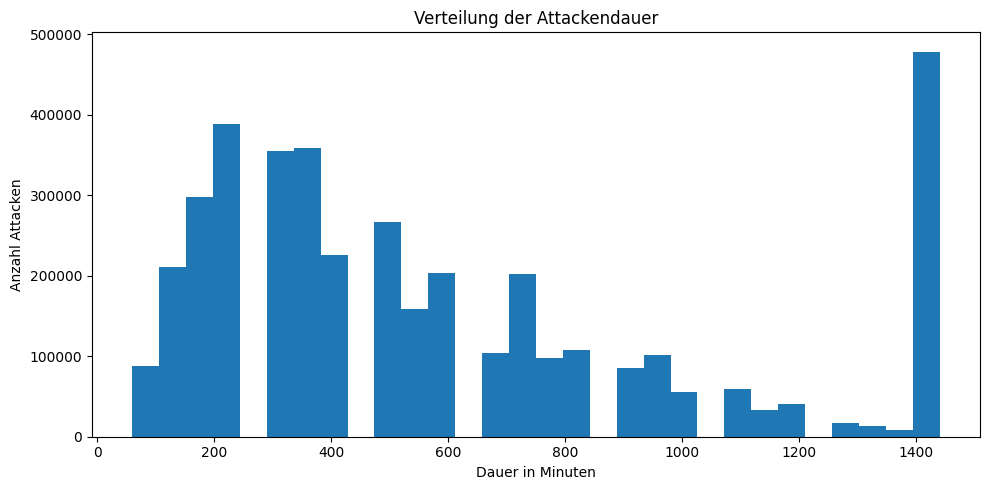

In [45]:
# ------------------------------------------------------------
# 6. Duration distribution
# ------------------------------------------------------------

duration_data = df_analysis["duration"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(duration_data, bins=30)

plt.title("Verteilung der Attackendauer")
plt.xlabel("Dauer in Minuten")
plt.ylabel("Anzahl Attacken")

save_or_show("06_duration_distribution_attacks.png")

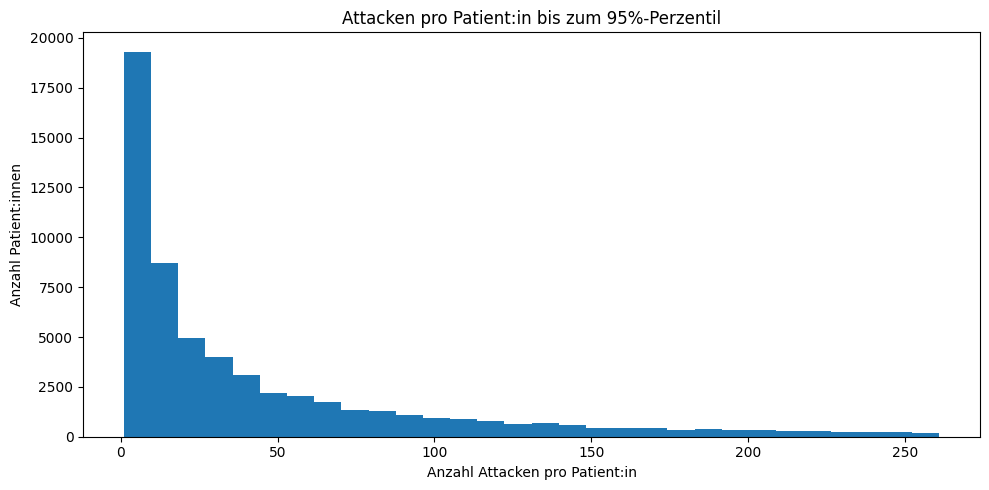

95%-Perzentil Attacken pro Patient:in: 261.0


In [46]:
# ------------------------------------------------------------
# 7. Attacks per patient distribution
# ------------------------------------------------------------

if "attacks_per_patient" in globals():
    attacks_per_patient_plot = attacks_per_patient["anzahl_attacken"].dropna()
else:
    attacks_per_patient_plot = (
        df_analysis
        .groupby("patient_id")
        .agg(anzahl_attacken=("attack_id", "count"))
        ["anzahl_attacken"]
        .dropna()
    )

cap_95 = attacks_per_patient_plot.quantile(0.95)

attacks_per_patient_capped = attacks_per_patient_plot[
    attacks_per_patient_plot <= cap_95
]

plt.figure(figsize=(10, 5))

plt.hist(attacks_per_patient_capped, bins=30)

plt.title("Attacken pro Patient:in bis zum 95%-Perzentil")
plt.xlabel("Anzahl Attacken pro Patient:in")
plt.ylabel("Anzahl Patient:innen")

save_or_show("07_attacks_per_patient_distribution_capped_95.png")

print("95%-Perzentil Attacken pro Patient:in:", cap_95)

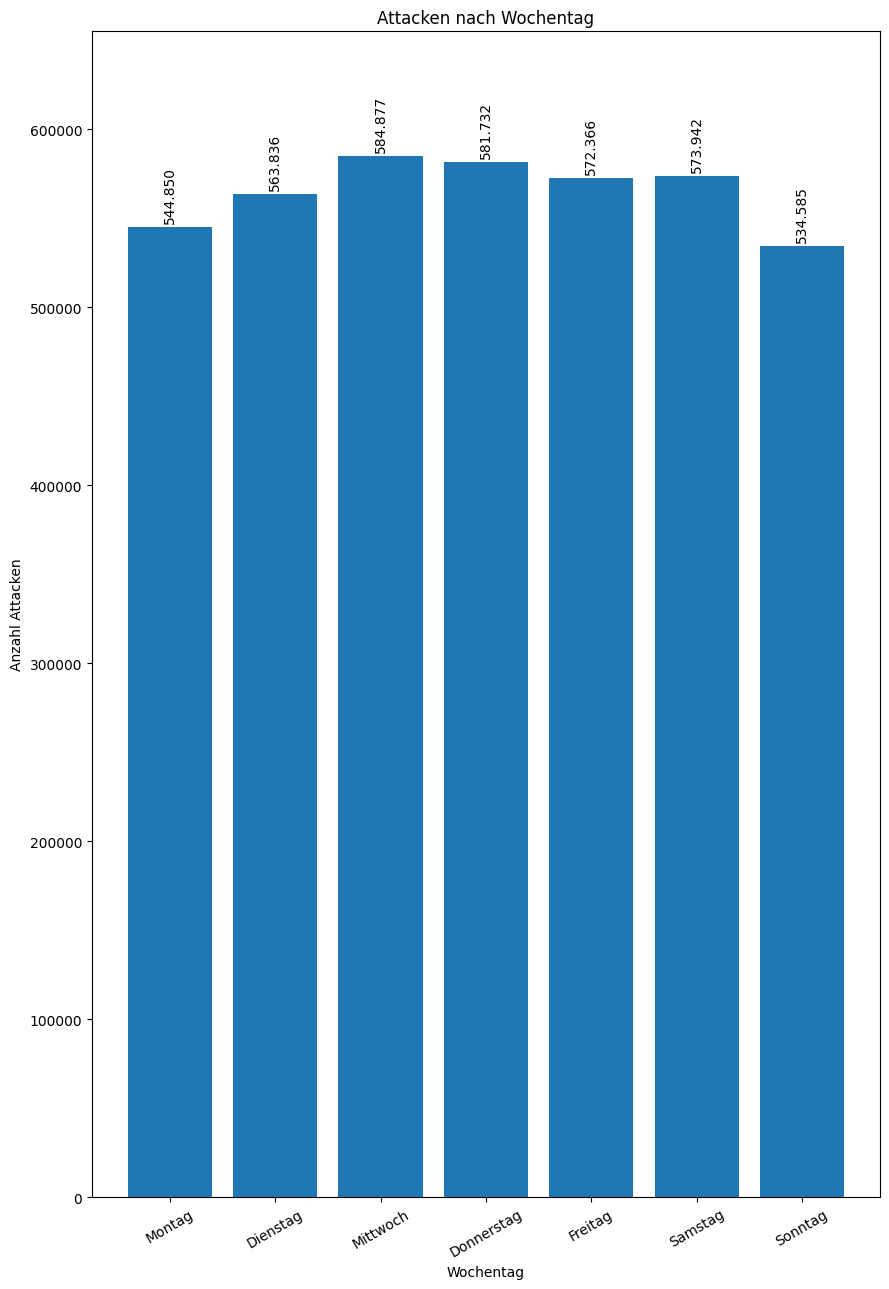

In [47]:
# ------------------------------------------------------------
# 8. Weekday distribution of attacks
# ------------------------------------------------------------

weekday_order = [
    "Montag",
    "Dienstag",
    "Mittwoch",
    "Donnerstag",
    "Freitag",
    "Samstag",
    "Sonntag"
]

if "weekday_summary" in globals():
    plot_data = weekday_summary.copy()
else:
    plot_data = (
        df_analysis
        .groupby("weekday_name")
        .agg(
            anzahl_attacken=("attack_id", "count"),
            anzahl_patienten=("patient_id", "nunique")
        )
        .reset_index()
    )

plot_data["weekday_name"] = pd.Categorical(
    plot_data["weekday_name"].astype(str),
    categories=weekday_order,
    ordered=True
)

plot_data = plot_data.sort_values("weekday_name")

plt.figure(figsize=(9, 13))
ax = plt.gca()

ax.bar(
    plot_data["weekday_name"].astype(str),
    plot_data["anzahl_attacken"]
)

add_value_labels(ax, rotation=90)

plt.title("Attacken nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Anzahl Attacken")
plt.xticks(rotation=30)

save_or_show("08_weekday_distribution_attacks.png")

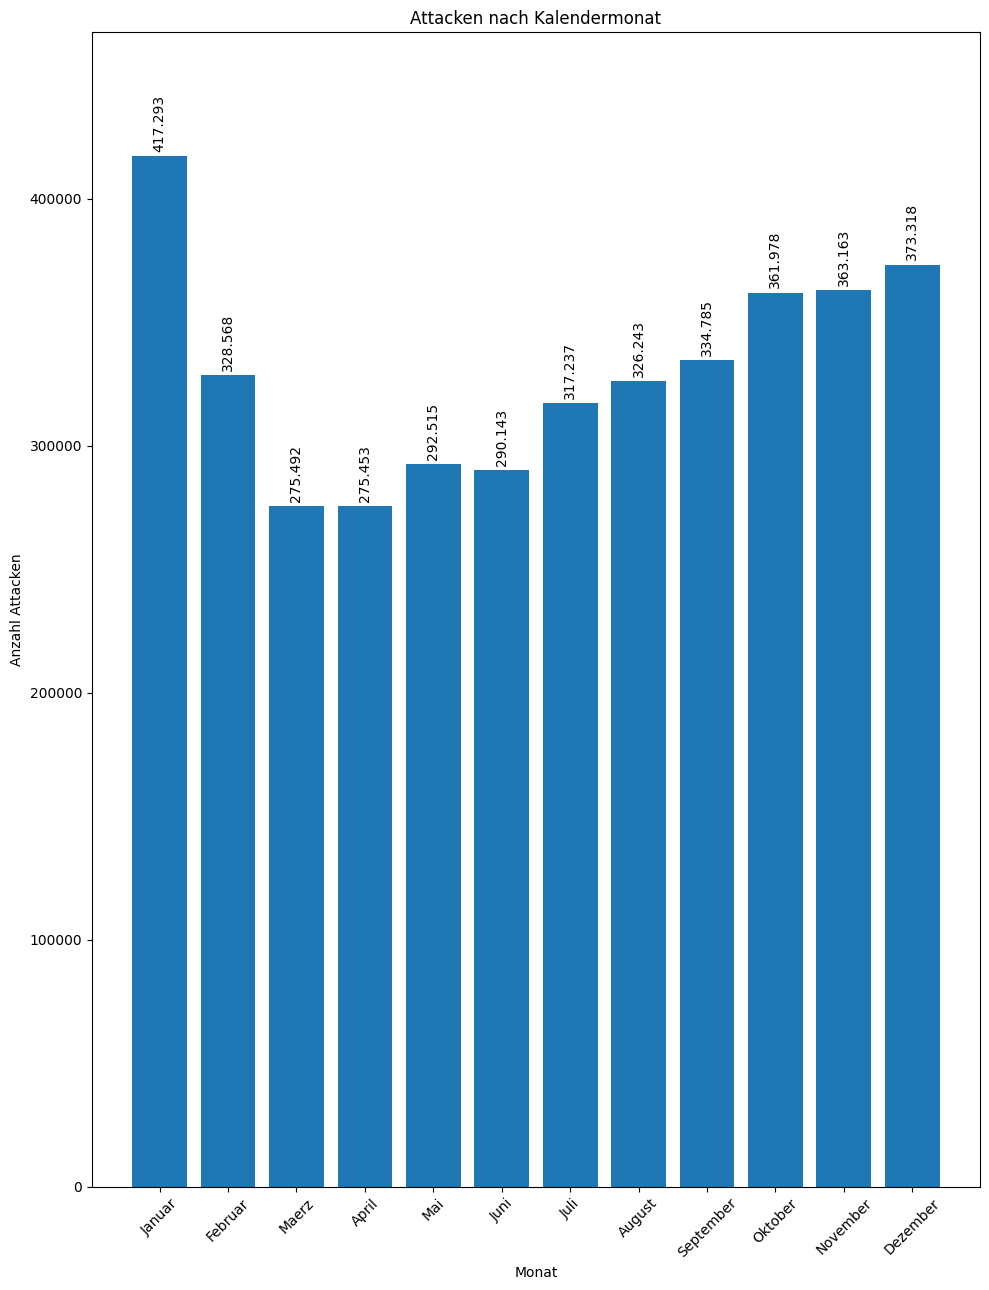

In [48]:
# ------------------------------------------------------------
# 9. Month distribution of attacks
# ------------------------------------------------------------

month_order = [
    "Januar",
    "Februar",
    "Maerz",
    "April",
    "Mai",
    "Juni",
    "Juli",
    "August",
    "September",
    "Oktober",
    "November",
    "Dezember"
]

if "month_summary" in globals():
    plot_data = month_summary.copy()
else:
    plot_data = (
        df_analysis
        .groupby("month_name")
        .agg(
            anzahl_attacken=("attack_id", "count"),
            anzahl_patienten=("patient_id", "nunique")
        )
        .reset_index()
    )

plot_data["month_name"] = pd.Categorical(
    plot_data["month_name"].astype(str),
    categories=month_order,
    ordered=True
)

plot_data = plot_data.sort_values("month_name")

plt.figure(figsize=(10, 13))
ax = plt.gca()

ax.bar(
    plot_data["month_name"].astype(str),
    plot_data["anzahl_attacken"]
)

add_value_labels(ax, rotation=90)

plt.title("Attacken nach Kalendermonat")
plt.xlabel("Monat")
plt.ylabel("Anzahl Attacken")
plt.xticks(rotation=45)

save_or_show("09_month_distribution_attacks.png")

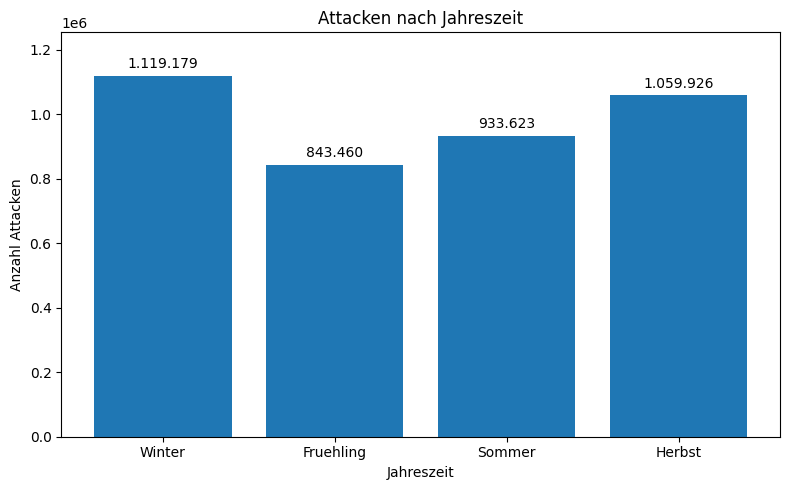

In [49]:
# ------------------------------------------------------------
# 10. Season distribution of attacks
# ------------------------------------------------------------

season_order = ["Winter", "Fruehling", "Sommer", "Herbst"]

if "season_summary" in globals():
    plot_data = season_summary.copy()
else:
    plot_data = (
        df_analysis
        .groupby("season")
        .agg(
            anzahl_attacken=("attack_id", "count"),
            anzahl_patienten=("patient_id", "nunique")
        )
        .reset_index()
    )

plot_data["season"] = pd.Categorical(
    plot_data["season"].astype(str),
    categories=season_order,
    ordered=True
)

plot_data = plot_data.sort_values("season")

plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.bar(
    plot_data["season"].astype(str),
    plot_data["anzahl_attacken"]
)

add_value_labels(ax)

plt.title("Attacken nach Jahreszeit")
plt.xlabel("Jahreszeit")
plt.ylabel("Anzahl Attacken")

save_or_show("10_season_distribution_attacks.png")


Monatlicher Verlauf der dokumentierten Attacken


,attack_datetime,anzahl_attacken,anzahl_patienten
0,2020-06-30,32,12
1,2020-07-31,604,93
2,2020-08-31,1282,161
3,2020-09-30,1906,227
4,2020-10-31,2847,353


,attack_datetime,anzahl_attacken,anzahl_patienten
64,2025-10-31,161159,20004
65,2025-11-30,156699,20328
66,2025-12-31,161045,20355
67,2026-01-31,176919,22106
68,2026-02-28,90216,19877


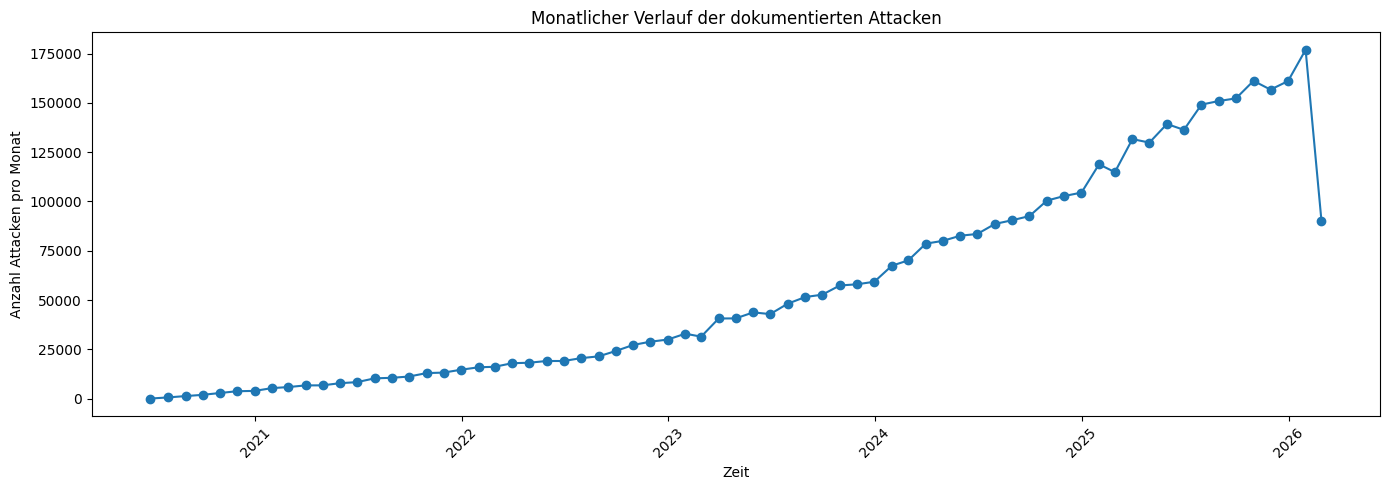

In [50]:
# ------------------------------------------------------------
# 11. Monthly time trend of attacks
# ------------------------------------------------------------

print("\nMonatlicher Verlauf der dokumentierten Attacken")

# Make sure attack_datetime is datetime
df_analysis["attack_datetime"] = pd.to_datetime(
    df_analysis["attack_datetime"],
    errors="coerce"
)

monthly_trend = (
    df_analysis
    .dropna(subset=["attack_datetime"])
    .set_index("attack_datetime")
    .resample("ME")
    .agg(
        anzahl_attacken=("attack_id", "count"),
        anzahl_patienten=("patient_id", "nunique")
    )
    .reset_index()
)

display(monthly_trend.head())
display(monthly_trend.tail())

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_trend["attack_datetime"],
    monthly_trend["anzahl_attacken"],
    marker="o"
)

plt.title("Monatlicher Verlauf der dokumentierten Attacken")
plt.xlabel("Zeit")
plt.ylabel("Anzahl Attacken pro Monat")
plt.xticks(rotation=45)

save_or_show("11_monthly_time_trend_attacks.png")